# 01 - изучить модель SmolVLA 

Цель notebook: пока просто скачать + проверить совместимость с датасетом

Скачаем `lerobot/smolvla_base` у неё pretrain модули это 

In [16]:
from pathlib import Path
from huggingface_hub import snapshot_download
from lerobot.configs import PreTrainedConfig
from pprint import pprint
import torch

ROOT_DIR = Path.cwd().resolve().parent

BASE_MODEL_DIR = ROOT_DIR / "models" / "smolvla_base"

In [11]:
# snapshot_download(
#     repo_id="lerobot/smolvla_base",
#     repo_type="model",
#     local_dir=BASE_MODEL_DIR,
# )

## Инженерные проблемы, с которыми столкнулся 

Я понял, что надо переименовывать так как в dataset от nvidia они называются по другому:\
```
rename_map='{
    "observation.images.image":"observation.images.camera1", 
    "observation.images.wrist_image":"observation.images.camera2", 
    "observation.images.image2":"observation.images.camera2" 
}'
``` 
`wrist_image` ещё заменяется на image2 [тут](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/envs/utils.py#L80) 

Нормировка картинок в libero в [0, 1] (я проверил глазками на всякий случай) в конце ноутбука 00 \
И потом она идёт в smolvla в [lerobot](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/policies/smolvla/modeling_smolvla.py#L360)
`img = img * 2.0 - 1.0`

И также smolvla_base имеет размерность action [6] при инициализации \

А данные в `nvidia/LIBERO_LeRobot_v3` у action [7] (как я понял подаётся ещё gripper) \
И но так как происходит [padding](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/policies/smolvla/modeling_smolvla.py#L417) до [max_action_dim: int = 32](https://github.com/huggingface/lerobot/blob/22bd7a2f489b367d8df42de803b1e8c4ca63a3f9/src/lerobot/policies/smolvla/configuration_smolvla.py#L42) то у нас идёт все обучение с размерностью как `nvidia/LIBERO_LeRobot_v3`

Аналогично со state 



В окружении изменить этот файл:
`.venv/lib/python3.12/site-packages/lerobot/scripts/lerobot_eval.py`

В этом блоке поменять:
```python
action_transition = {ACTION: action}
action_transition = env_postprocessor(action_transition)
action = action_transition[ACTION]

# Convert to CPU / numpy.
action_numpy: np.ndarray = action.to("cpu").numpy()
```

Вставить между `action = action_transition[ACTION] и action_numpy:`

Чтобы стало так:
```python
action_transition = {ACTION: action}
action_transition = env_postprocessor(action_transition)
action = action_transition[ACTION]

if action.shape[-1] >= 7:
    action = action.clone()
    gripper = action[..., 6]
    action[..., 6] = 1.0 - 2.0 * (gripper > 0.5).to(action.dtype)

# Convert to CPU / numpy.
action_numpy: np.ndarray = action.to("cpu").numpy()
```

Это изменяет поведение для проведения rollout:

dataset/model gripper > 0.5 -> -1 open

dataset/model gripper <= 0.5 -> +1 close

## Про саму модель (черновик) [статья](https://arxiv.org/pdf/2506.01844)

Архитектура состоит из двух крупных частей: \
VLM -> Action Expert

VLM отвечает в основном за понимание сцены и задания, а Action Expert преобразует это представление в непрерывные управляющие воздействия. В качестве VLM используется SmolVLM-2 с SigLIP vision encoder и SmolLM2 language decoder

Интересные решения, что я подчеркнул для себя:
- VLM специально урезают (и вроде достаточно использовать половину) + VLM при обучении policy заморожен
- Action Expert - отдельный Transformer примерно на 100M параметров. Он генерирует сразу последовательность: \
    $ A_t = [a_t, a_{t+1}, ..., a_{t+n}]  \;\;\; (n = 50)$ \
    Идёт чередование слоёв: Cross Attention -> Self Attention -> Cross Attention ... \
    Cross Attention: q из action tokens; k,v из признаки(токены??) с vlm \
    Self Attention позволяет различным будущим action tokens взаимодействовать друг с другом( не очень понял как по нормальному написать ) \ 
- Flow Matching: для истинного action chunk $A_t$ формируется зашумлённая версия $A_t^\tau=(1-\tau)A_t+\tau\epsilon$, где $\epsilon\sim\mathcal{N}(0,I)$.
Модель $v_\theta(A_t^\tau,obs_t,\tau)$ по признакам VLM и зашумлённым действиям предсказывает векторное поле $u=\epsilon-A_t$, минимизируя $\mathcal{L}=\|v_\theta-u\|_2^2$.





# Про первую стадию 

## Seen-претрен

- Дообучил smolvla_base на seen-части. \
- Это график running_success_rate на task_ids = `[0,15,20,40,57,60,67,70]`  по 3 эпизода (все task_ids не стал перебирать)


![alt text](success.png)
При этом zero-shot success_rate = 0 (на разных ckpt) по задачам 0-2 из libero_goal, я это объясняю так: 

1. Это не те же самые задачи: \
    Целевые: \
    0: open the middle drawer of the cabinet \
    1: put the bowl on the stove \
    2: put the wine bottle on top of the cabinet 

    В seen libero_90 есть похожие куски, но поятное дело не ровно они: \
    есть open top drawer, open bottom drawer, но не middle drawer \
    есть put frying pan/moka pot on stove, но не bowl on stove \
    есть wine bottle in bottom drawer и wine bottle on wine rack, но не wine bottle on top of cabinet 

    При этом действия робота разные при разных задачах(0, 1, 2), а значит task_text всё-таки влияет 

2. libero_90 в твоём датасете в основном учит primitives: \
    put/place: 32 задачи \
    pick up ... put/place: 25 задач \
    open: 4\
    close: 8\
    stack: 4\
    turn on/off stove: 3\
    То есть модель хорошо может выучить "как управлять рукой", но zero-shot требует понять новую комбинацию объект + место + цель. 

Так как pretrain не произвёл особого успеха на zero-shot задачах, выберу один из максимальных, зафиксирую его и буду работать с ним:

Максимальный libero_90 success: 030000, 070000, 076000 = 91.7%
- 030000 я бы не брал первым: слишком ранний, может быть шум.
- 076000 тоже пик, но выглядит более одиночным скачком.
- Район 068000-076000 в целом самый сильный, поэтому **070000** выглядит хорошим кандидатом.



## Наивный файнтюн моего чекпойнта

Naive fine-tuning baseline.

Я отдельно дообучал seen-чекпойнт на каждой из трёх held-out задач из LIBERO Goal. Для каждой задачи использовались первые по порядку 5, 10 или 25 demonstrations из датасета (без выбора удачных эпизодов).

Дообучение запускалось без дополнительных ухищрений: тот же SmolVLA policy, тот же preprocessing/rename_map, фиксированный seed=1000, checkpoint 070000 как стартовая точка. Для каждой пары task_id и числа demonstrations обучался отдельный run, после чего checkpoint 005000 оценивался на той же target-задаче в LIBERO env.

Я фиксировал не число эпох, а steps (число optimizer updates): 5000 шагов для всех настроек. Поэтому compute budget одинаковый, но число эффективных эпох разное: маленький набор из 5 demo проходится больше раз, чем 25 demo. Это осознанный выбор для baseline, потому что я сравниваю количество demo при одинаковом бюджете дообучения.

,task_id,demos,success_percent,n_episodes
0,0,5,68.0,50
1,0,10,100.0,50
2,0,25,94.0,50
3,1,5,94.0,50
4,1,10,92.0,50
5,1,25,94.0,50
6,2,5,88.0,50
7,2,10,92.0,50
8,2,25,94.0,50


,demos,mean_success_percent
0,5,83.333333
1,10,94.666667
2,25,94.000000


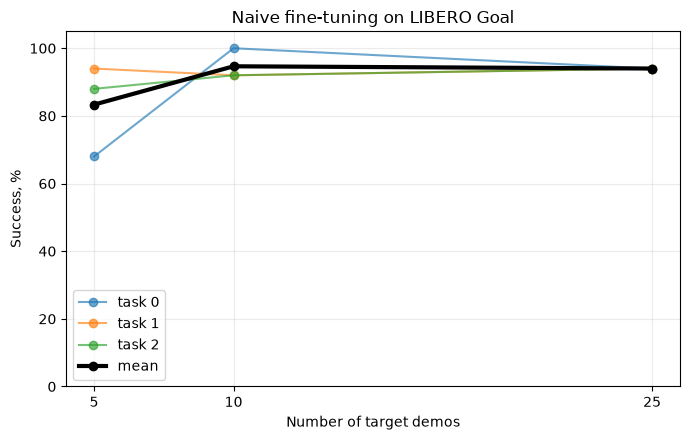

In [5]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..")
TASKS = [0, 1, 2]
DEMOS = [5, 10, 25]
CKPT = "005000"

rows = []

for task_id in TASKS:
    for demos in DEMOS:
        run = f"smolvla_libero90_pretrained_finetune_t{task_id}_d{demos}"
        path = ROOT / "logs" / run / f"{CKPT}_libero_goal_{task_id}" / "eval_info.json"

        with open(path) as f:
            info = json.load(f)

        rows.append({
            "task_id": task_id,
            "demos": demos,
            "success_percent": info["overall"]["pc_success"],
            "n_episodes": info["overall"]["n_episodes"],
        })

df = pd.DataFrame(rows).sort_values(["task_id", "demos"])
display(df)

mean_df = (
    df.groupby("demos", as_index=False)
      .agg(mean_success_percent=("success_percent", "mean"))
)

display(mean_df)

plt.figure(figsize=(7, 4.5))

for task_id in TASKS:
    part = df[df["task_id"] == task_id]
    plt.plot(
        part["demos"],
        part["success_percent"],
        marker="o",
        linewidth=1.5,
        alpha=0.65,
        label=f"task {task_id}",
    )

plt.plot(
    mean_df["demos"],
    mean_df["mean_success_percent"],
    marker="o",
    linewidth=3,
    color="black",
    label="mean",
)

plt.xticks(DEMOS)
plt.ylim(0, 105)
plt.xlabel("Number of target demos")
plt.ylabel("Success, %")
plt.title("Naive fine-tuning on LIBERO Goal")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Перед дальнейшими запусками ожидаю резкий рост success от 0 к 5 target demonstrations, затем насыщение примерно к 10 demonstrations. Результат на 25 demonstrations может быть на том же уровне или немного ниже из-за шума обучения и eval.

Основная причина: seen checkpoint уже обучался на LIBERO-90 и должен иметь базовые visuomotor-навыки: reaching, движение руки, взаимодействие с объектами. Поэтому небольшое число target demonstrations должно в основном донастроить модель под конкретную held-out goal-задачу и её языковую инструкцию.